# Ejercicio de programación - Regresión Logística

En este ejercicio se implementa regresión logística desde cero y se aplica a un **dataset real de clasificación binaria**.

Se utilizará el dataset **Banknote Authentication** del UCI Machine Learning Repository. Los datos fueron extraídos de imágenes de muestras de billetes genuinos y falsificados mediante transformaciones wavelet.

**Fuente:** Volker Lohweg (2012), *Banknote Authentication*, UCI Machine Learning Repository. DOI: 10.24432/C55P57.


## Preparación del entorno

El dataset se descargará directamente desde Internet, por lo que **no es necesario montar Google Drive ni subir archivos manualmente**. Esto hace que el cuadernillo pueda ejecutarse directamente en Google Colab.


In [1]:
# Librerías para manejo de datos y cálculo científico
import numpy as np
import pandas as pd

# Librería para graficar
from matplotlib import pyplot

# Módulo de optimización de SciPy
from scipy import optimize

# Incrusta los gráficos en el cuaderno
%matplotlib inline


## 1 Regresión Logística

En esta parte del ejercicio se construirá un modelo de regresión logística para clasificar registros del dataset **Banknote Authentication**.

El conjunto original contiene **1372 registros**, cuatro características numéricas y una clase binaria. Para mantener el ejercicio comparable con la versión original y poder representar el límite de decisión en dos dimensiones, se utilizarán únicamente estas dos variables:

- **variance**: varianza de la imagen transformada mediante wavelet.
- **skewness**: asimetría de la imagen transformada mediante wavelet.

La variable objetivo será **class**, con valores 0 y 1.

La siguiente celda descarga los datos directamente desde el repositorio oficial de UCI y selecciona las dos características que se utilizarán en el modelo.


In [2]:
# URL oficial del archivo de datos en UCI Machine Learning Repository
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt'

# El archivo no contiene encabezados, por lo que se asignan los nombres publicados por UCI
columnas = ['variance', 'skewness', 'curtosis', 'entropy', 'class']
df = pd.read_csv(url, header=None, names=columnas)

# Para conservar una visualización bidimensional se usan solo dos características
X = df[['variance', 'skewness']].to_numpy(dtype=float)
y = df['class'].to_numpy(dtype=float)

print('Dimensiones del dataset completo:', df.shape)
print('Dimensiones de X:', X.shape)
print('Dimensiones de y:', y.shape)
print()
print('Primeros registros:')
print(df.head())
print()
print('Distribución de clases:')
print(df['class'].value_counts().sort_index())


Dimensiones del dataset completo: (1372, 5)
Dimensiones de X: (1372, 2)
Dimensiones de y: (1372,)

Primeros registros:
   variance  skewness  curtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0

Distribución de clases:
class
0    762
1    610
Name: count, dtype: int64


### 1.1 Visualizar los datos

Antes de implementar el algoritmo de aprendizaje, es útil visualizar los datos. La función `plotData` mostrará una figura bidimensional donde los ejes corresponden a **variance** y **skewness**. Los ejemplos de clase 1 y clase 0 se mostrarán con marcadores diferentes.


In [3]:
def plotData(X, y):
    # Grafica los puntos de datos X e y en una nueva figura.
    # Usa * para los ejemplos de clase 1 y o para los ejemplos de clase 0.

    fig = pyplot.figure()

    # Índices de ejemplos positivos y negativos
    pos = y == 1
    neg = y == 0

    # Graficar ejemplos
    pyplot.plot(X[pos, 0], X[pos, 1], 'k*', lw=2, ms=8)
    pyplot.plot(X[neg, 0], X[neg, 1], 'ko', mfc='y', ms=5, mec='k', mew=1)


Se llama a la función implementada para mostrar los datos cargados:


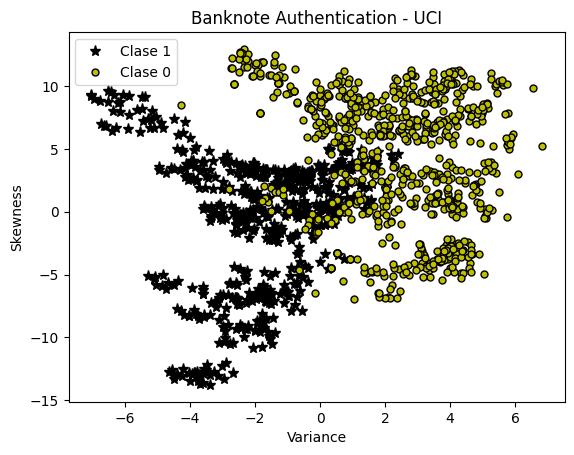

In [4]:
plotData(X, y)
pyplot.xlabel('Variance')
pyplot.ylabel('Skewness')
pyplot.legend(['Clase 1', 'Clase 0'])
pyplot.title('Banknote Authentication - UCI')
pass


<a id="section1"></a>
### 1.2 Implementacion

#### 1.2.1 Fución Sigmoidea

La hipotesis para la regresión logistica se define como:

$$ h_\theta(x) = g(\theta^T x)$$

donde la función $g$ is la función sigmoidea. La función sigmoidea se define como:

$$g(z) = \frac{1}{1+e^{-z}}$$.

Los resultados que debe generar la funcion sigmoidea para valores positivos amplios de `x`, deben ser cercanos a 1, mientras que para valores negativos grandes, la sigmoide debe generar valores cercanos 0. La evaluacion de `sigmoid(0)` debe dar un resultado exacto de 0.5. Esta funcion tambien debe poder trabajar con vectores y matrices.

In [5]:
def sigmoid(z):
    # Calcula la sigmoide de una entrada z
    # convierte la intrada a un arreglo numpy
    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

Se calcula el valor de la sigmoide aplicando la función `sigmoid`. Para `z = 0` se debe obtener exactamente 0.5. Se recomienda experimentar con otros valores de `z`.


In [6]:
# Prueba la implementacion de la funcion sigmoid
z = [-100, 0.5, 1000000]
g = sigmoid(z)

print('g(', z, ') = ', g)

g( [-100, 0.5, 1000000] ) =  [3.72007598e-44 6.22459331e-01 1.00000000e+00]


#### 1.2.2 Función de Costo y Gradiente

Se implementan las funciones de costo y gradiente para la regresión logística. Antes de continuar es importante agregar el término de intercepción a `X`.


In [7]:
# Configurar la matriz adecuadamente y agregar una columna de unos
# que corresponde al término de intercepción.
m, n = X.shape
X = np.concatenate([np.ones((m, 1)), X], axis=1)

print('Nueva dimensión de X con intercepción:', X.shape)


Nueva dimensión de X con intercepción: (1372, 3)


La funcion de costo en una regresión logistica es:

$$ J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ -y^{(i)} \log\left(h_\theta\left( x^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - h_\theta\left( x^{(i)} \right) \right) \right]$$

y el gradiente del costo es un vector de la misma longitud como $\theta$ donde el elemento $j^{th}$ (para $j = 0, 1, \cdots , n$) se define como:

$$ \frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^m \left( h_\theta \left( x^{(i)} \right) - y^{(i)} \right) x_j^{(i)} $$

Si bien este gradiente parece idéntico al gradiente de regresión lineal, la fórmula es diferente porque la regresión lineal y logística tienen diferentes definiciones de $h_\theta(x)$.
<a id="costFunction"></a>

In [8]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores útiles
    m = y.size  # número de ejemplos de entrenamiento

    h = sigmoid(X.dot(theta.T))

    # Evita log(0) por estabilidad numérica
    h = np.clip(h, 1e-12, 1 - 1e-12)

    J = (1 / m) * np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h))
    return J


In [9]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0]  # número de ejemplos de entrenamiento

    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)
        J_history.append(calcularCosto(theta, X, y))

    return theta, J_history


Theta calculado por descenso por gradiente: [ 0.55497435 -1.10283693 -0.26898251]
Costo final: 0.2631621801823725
Probabilidad estimada de pertenecer a la clase 1 para variance=3.6216 y skewness=8.6661: 0.0031


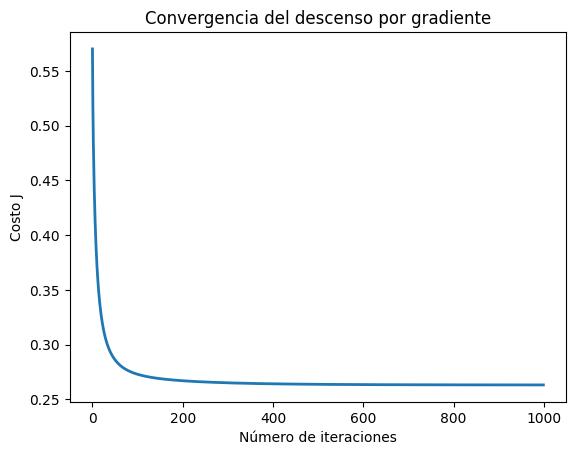

In [10]:
# Elegir un valor para alpha
alpha = 0.05
num_iters = 1000

# Inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(3)
theta, J_history = descensoGradiente(theta, X, y, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del descenso por gradiente')

print('Theta calculado por descenso por gradiente:', theta)
print('Costo final:', J_history[-1])

# Ejemplo de predicción usando valores dentro del rango del dataset
X_array = [1, 3.6216, 8.6661]
prob_clase_1 = sigmoid(np.dot(X_array, theta))

print('Probabilidad estimada de pertenecer a la clase 1 para variance=3.6216 y skewness=8.6661: {:.4f}'.format(prob_clase_1))


In [11]:
# Segundo ejemplo de predicción
X_array = [1, -3.0, -5.0]
y_predicted = sigmoid(np.dot(X_array, theta))
print('Probabilidad de pertenecer a la clase 1 para variance=-3.0 y skewness=-5.0: {:.4f}'.format(y_predicted))


Probabilidad de pertenecer a la clase 1 para variance=-3.0 y skewness=-5.0: 0.9946


In [12]:
def costFunction(theta, X, y):
    # Inicializar algunos valores útiles
    m = y.size

    h = sigmoid(X.dot(theta.T))
    h = np.clip(h, 1e-12, 1 - 1e-12)

    J = (1 / m) * np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h))
    grad = (1 / m) * (h - y).dot(X)

    return J, grad


Se prueba la función `costFunction` utilizando dos casos para $\theta$. Los valores esperados se actualizaron para el dataset Banknote Authentication.


In [13]:
# Inicialización de parámetros de ajuste
initial_theta = np.zeros(n + 1)
cost, grad = costFunction(initial_theta, X, y)

print('Costo en theta inicial (zeros): {:.6f}'.format(cost))
print('Costo esperado (aproximado): 0.693147')
print()
print('Gradiente en theta inicial (zeros):')
print('\t[{:.4f}, {:.4f}, {:.4f}]'.format(*grad))
print('Gradiente esperado (aproximado):')
print('\t[0.0554, 1.0476, 1.4029]')


Costo en theta inicial (zeros): 0.693147
Costo esperado (aproximado): 0.693147

Gradiente en theta inicial (zeros):
	[0.0554, 1.0476, 1.4029]
Gradiente esperado (aproximado):
	[0.0554, 1.0476, 1.4029]


In [14]:
# Calcula y muestra el costo y el gradiente con valores de theta diferentes de cero
test_theta = np.array([0.5, -1.0, -0.25])
cost, grad = costFunction(test_theta, X, y)

print('Costo en theta de prueba: {:.6f}'.format(cost))
print('Costo esperado (aproximado): 0.264338')
print()
print('Gradiente en theta de prueba:')
print('\t[{:.4f}, {:.4f}, {:.4f}]'.format(*grad))
print('Gradiente esperado (aproximado):')
print('\t[-0.0015, 0.0200, 0.0078]')


Costo en theta de prueba: 0.264338
Costo esperado (aproximado): 0.264338

Gradiente en theta de prueba:
	[-0.0015, 0.0200, 0.0078]
Gradiente esperado (aproximado):
	[-0.0015, 0.0200, 0.0078]


#### 1.2.3 Parámetros de aprendizaje usando `scipy.optimize`

En el código anterior se encontraron parámetros mediante descenso por gradiente. Otra alternativa es utilizar `scipy.optimize.minimize`, que busca directamente los parámetros que minimizan la función de costo.

Para este ejercicio se proporciona a `optimize.minimize`:

- `costFunction`: calcula simultáneamente el costo y el gradiente.
- `initial_theta`: valores iniciales de los parámetros.
- `(X, y)`: datos de entrenamiento.
- `jac=True`: indica que la función devuelve también el gradiente.
- `method='TNC'`: algoritmo de optimización utilizado.

A continuación se calcula el valor óptimo de $\theta$ para las dos variables seleccionadas del dataset Banknote Authentication.


In [15]:
# Opciones para optimize.minimize
options = {'maxfun': 1000}

res = optimize.minimize(costFunction,
                        initial_theta,
                        (X, y),
                        jac=True,
                        method='TNC',
                        options=options)

cost = res.fun
theta = res.x

print('¿Convergió?:', res.success)
print('Mensaje:', res.message)
print('Costo con theta optimizado: {:.6f}'.format(cost))
print('Costo esperado (aproximado): 0.263131')
print()
print('Theta optimizado:')
print('\t[{:.6f}, {:.6f}, {:.6f}]'.format(*theta))
print('Theta esperado (aproximado):')
print('\t[0.586679, -1.110759, -0.272564]')


¿Convergió?: True
Mensaje: Converged (|f_n-f_(n-1)| ~= 0)
Costo con theta optimizado: 0.263131
Costo esperado (aproximado): 0.263131

Theta optimizado:
	[0.586679, -1.110759, -0.272564]
Theta esperado (aproximado):
	[0.586679, -1.110759, -0.272564]


Una vez completada la optimización, se usa el valor final de $\theta$ para visualizar el **límite de decisión** sobre los datos de entrenamiento.


In [16]:
def plotDecisionBoundary(plotData, theta, X, y):
    """Grafica los datos y el límite de decisión definido por theta."""
    theta = np.array(theta)

    # Graficar los datos sin la columna de intercepción
    plotData(X[:, 1:3], y)

    if X.shape[1] <= 3:
        # Dos puntos son suficientes para definir la recta de decisión
        margen_x = 0.5
        plot_x = np.array([np.min(X[:, 1]) - margen_x,
                           np.max(X[:, 1]) + margen_x])

        # theta0 + theta1*x1 + theta2*x2 = 0
        plot_y = (-1.0 / theta[2]) * (theta[1] * plot_x + theta[0])

        pyplot.plot(plot_x, plot_y)
        pyplot.legend(['Clase 1', 'Clase 0', 'Límite de decisión'])

        # Límites dinámicos adecuados al nuevo dataset
        margen_y = 1.0
        pyplot.xlim([np.min(X[:, 1]) - margen_x, np.max(X[:, 1]) + margen_x])
        pyplot.ylim([np.min(X[:, 2]) - margen_y, np.max(X[:, 2]) + margen_y])
        pyplot.xlabel('Variance')
        pyplot.ylabel('Skewness')
        pyplot.title('Límite de decisión - Regresión logística')


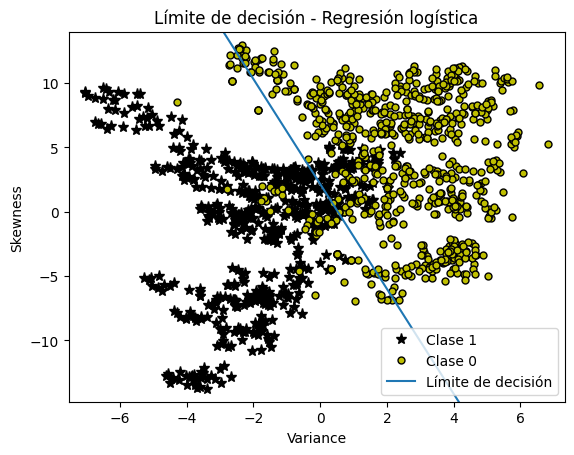

In [17]:
# Graficar limites
plotDecisionBoundary(plotData, theta, X, y)

#### 1.2.4 Evaluación de la regresión logística

Después de aprender los parámetros, el modelo puede calcular la probabilidad de que un registro pertenezca a la **clase 1**. También se evaluará qué porcentaje de los registros del conjunto utilizado para entrenamiento es clasificado correctamente.


In [18]:
def predict(theta, X):
    """
    Predecir si la etiqueta es 0 o 1 mediante regresión logística aprendida.
    Calcula las predicciones para X usando un umbral en 0.5 (es decir, si sigmoide (theta.T * x)> = 0.5, predice 1)

    Parametros
    ----------
    theta : array_like
        Parametros para regresion logistica. Un vecto de la forma (n+1, ).

    X : array_like
        Datos utilizados para el calculo de las predicciones.
        La fila es el numero de los puntos para calcular las predicciones,
        y las columnas con el numero de caracteristicas.

    Devuelve
    -------
    p : array_like
        Predicciones y 0 o 1 para cada fila en X.
    """
    m = X.shape[0] # Numero de ejemplo de entrenamiento

    p = np.zeros(m)

    p = np.round(sigmoid(X.dot(theta.T)))
    return p

Una vez entrenado el modelo se procede a realizar una predicción de ejemplo y a calcular la precisión sobre los datos utilizados en el entrenamiento.


In [19]:
# Predicción para un registro de ejemplo
variance_ejemplo = -3.0
skewness_ejemplo = -5.0
prob = sigmoid(np.dot([1, variance_ejemplo, skewness_ejemplo], theta))

print('Para variance={} y skewness={}, la probabilidad estimada de clase 1 es: {:.4f}'.format(
    variance_ejemplo, skewness_ejemplo, prob))

# Precisión sobre el conjunto de entrenamiento
p = predict(theta, X)
accuracy = np.mean(p == y) * 100
print('Precisión de entrenamiento: {:.2f} %'.format(accuracy))
print('Precisión esperada aproximada usando solo variance y skewness: 88.56 %')


Para variance=-3.0 y skewness=-5.0, la probabilidad estimada de clase 1 es: 0.9949
Precisión de entrenamiento: 88.56 %
Precisión esperada aproximada usando solo variance y skewness: 88.56 %
